In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


TRAIN,TEST,VAL Generator

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define constants
IMG_SIZE = 224  # EfficientNetB0 default input size
BATCH_SIZE = 32

#  path to your pre-split datasets in Google Drive
train_dir = '/content/drive/MyDrive/pomegranate_split/train'
val_dir = '/content/drive/MyDrive/pomegranate_split/val'
test_dir = '/content/drive/MyDrive/pomegranate_split/test'

#data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Shuffling is usually disabled for the test set
)

# Calculate class weights for handling imbalanced classes
total_samples = sum([len(os.listdir(os.path.join(train_dir, class_name))) for class_name in os.listdir(train_dir)])
class_weights = {i: total_samples / (len(os.listdir(os.path.join(train_dir, class_name))) * len(os.listdir(train_dir)))
                 for i, class_name in enumerate(os.listdir(train_dir))}

print("\nClass weights:", class_weights)
print("Class indices:", train_generator.class_indices)


Found 4650 images belonging to 5 classes.
Found 997 images belonging to 5 classes.
Found 1003 images belonging to 5 classes.

Class weights: {0: 1.023102310231023, 1: 1.023102310231023, 2: 1.023102310231023, 3: 1.023102310231023, 4: 0.9171597633136095}
Class indices: {'Alternaria': 0, 'Anthracnose': 1, 'Bacterial_Blight': 2, 'Cercospora': 3, 'Healthy': 4}


MODEL ARCHITECTURE FOR EFFICIENTB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_model(num_classes, img_size=224):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # Freeze the entire base model initially
    base_model.trainable = False

    return model

# Build the model
num_classes = len(train_generator.class_indices)
model = build_model(num_classes)

# Print model summary
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer_2[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 8,613,443 (32.86 MB)

 Trainable params: 1,575,939 (6.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# Count total layers and frozen layers
total_layers = len(model.layers)
frozen_layers = sum([1 for layer in model.layers if not layer.trainable])

print(f"Total layers in the model: {total_layers}")
print(f"Number of frozen layers: {frozen_layers}")


Total layers in the model: 244
Number of frozen layers: 238


MODEL TRAINING EFFICIENTNETB0


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, LearningRateScheduler
import matplotlib.pyplot as plt

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 40
INITIAL_LEARNING_RATE = 1e-4
NUM_CLASSES = 5  # Adjust this based on your actual number of classes

# Create directories for saving model checkpoints and logs
checkpoint_dir = './model_checkpoints'
logs_dir = './training_logs'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

# Define the model architecture
def build_model(num_classes):
    base_model = tf.keras.applications.EfficientNetB0(weights=None, include_top=False, input_shape=(*IMG_SIZE, 3))

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model

# Learning rate schedule
def lr_schedule(epoch):
    lr = INITIAL_LEARNING_RATE
    if epoch > 18:
        lr *= 0.1
    if epoch > 29:
        lr *= 0.1
    return lr

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'model_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras'),
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    CSVLogger(os.path.join(logs_dir, 'training_log.csv'), append=True),
    LearningRateScheduler(lr_schedule)
]

# Function to find the latest epoch
def find_latest_checkpoint():
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith('.keras')]
    if not checkpoints:
        return None, 0
    latest = max(checkpoints, key=lambda x: os.path.getctime(os.path.join(checkpoint_dir, x)))
    epoch = int(latest.split('_')[2])
    return latest, epoch


# Load the latest model if it exists
specific_checkpoint = '/content/model_checkpoints/model_epoch_35_val_acc_0.9719.keras'  # Replace XXXX with actual accuracy value
initial_epoch = 35

try:
    model = tf.keras.models.load_model(os.path.join(checkpoint_dir, specific_checkpoint))
    print(f"Resuming training from epoch {initial_epoch}")
except:
    print(f"Failed to load the checkpoint {specific_checkpoint}. Please check the file name and path.")
    exit()

# Compile the model
optimizer = Adam(learning_rate=INITIAL_LEARNING_RATE, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save the final model
model.save('pomegranate_disease_classifier_final.keras')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Print final accuracy
final_accuracy = history.history['val_accuracy'][-1]
print(f"Final validation accuracy: {final_accuracy:.4f}")

Resuming training from epoch 35
Epoch 36/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9552 - loss: 0.1361 
Epoch 36: val_accuracy improved from -inf to 0.97091, saving model to ./model_checkpoints/model_epoch_36_val_acc_0.9709.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 1753s 12s/step - accuracy: 0.9552 - loss: 0.1361 - val_accuracy: 0.9709 - val_loss: 0.0853 - learning_rate: 1.0000e-06
Epoch 37/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9582 - loss: 0.1393 
Epoch 37: val_accuracy improved from 0.97091 to 0.97192, saving model to ./model_checkpoints/model_epoch_37_val_acc_0.9719.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 1705s 12s/step - accuracy: 0.9582 - loss: 0.1392 - val_accuracy: 0.9719 - val_loss: 0.0839 - learning_rate: 1.0000e-06
Epoch 38/40
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9591 - loss: 0.1245 
Epoch 38: val_accuracy improved from 0.97192 to 0.97392, saving model to ./model_checkpoints/model_epoch_38_val_acc_0.9739.keras
146/146 ━━━━━━━━━━━━━━━━

REPORT FOR EFFICIENTNETB0

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 322s 10s/step

Classification Report:
                  precision    recall  f1-score   support

      Alternaria       0.96      0.96      0.96       196
     Anthracnose       1.00      0.93      0.97       196
Bacterial_Blight       0.96      0.98      0.97       196
      Cercospora       0.95      0.98      0.96       196
         Healthy       0.99      1.00      0.99       219

        accuracy                           0.97      1003
       macro avg       0.97      0.97      0.97      1003
    weighted avg       0.97      0.97      0.97      1003



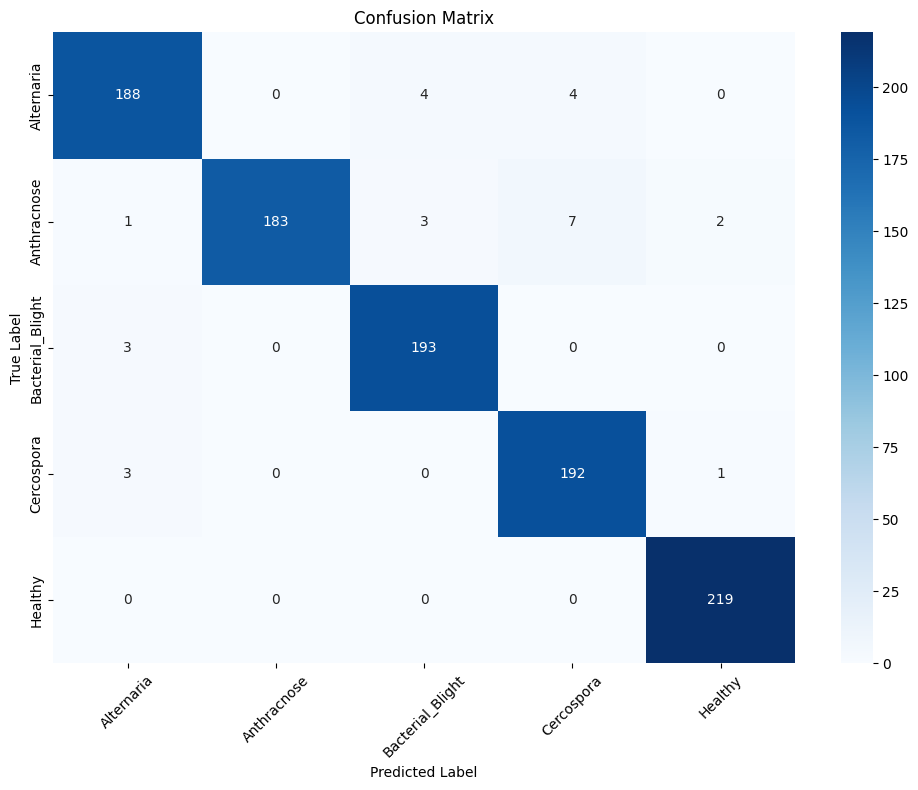


Overall Accuracy: 0.9720837487537388

Per-class Metrics:

Alternaria:
Precision: 0.9641
Recall: 0.9592
F1-score: 0.9616

Anthracnose:
Precision: 1.0000
Recall: 0.9337
F1-score: 0.9657

Bacterial_Blight:
Precision: 0.9650
Recall: 0.9847
F1-score: 0.9747

Cercospora:
Precision: 0.9458
Recall: 0.9796
F1-score: 0.9624

Healthy:
Precision: 0.9865
Recall: 1.0000
F1-score: 0.9932


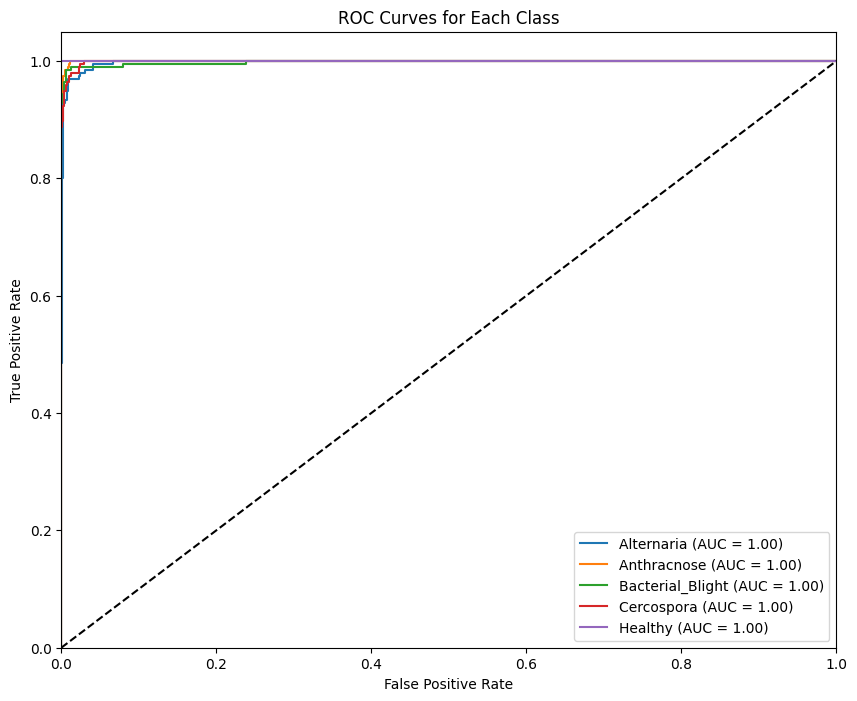

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model_path = '/content/drive/MyDrive/model_epoch_35_val_acc_0.9719.keras'  # Update with your model path
model = tf.keras.models.load_model(model_path)

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate and print metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate overall metrics
accuracy = np.sum(y_pred == y_true) / len(y_true)

# Calculate per-class metrics
class_metrics = {}
for i, class_name in enumerate(class_labels):
    true_class = (y_true == i)
    pred_class = (y_pred == i)

    # True Positives, False Positives, False Negatives
    tp = np.sum(true_class & pred_class)
    fp = np.sum(~true_class & pred_class)
    fn = np.sum(true_class & ~pred_class)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    class_metrics[class_name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Print detailed metrics
print("\nOverall Accuracy:", accuracy)
print("\nPer-class Metrics:")
for class_name, metrics in class_metrics.items():
    print(f"\n{class_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# Save predictions to a file (optional)
predictions_data = {
    'True Labels': y_true,
    'Predicted Labels': y_pred,
    'Class Names': [class_labels[i] for i in y_true]
}
np.save('model_predictions.npy', predictions_data)

# Calculate and visualize ROC curves for each class
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_true == i).astype(int)
    y_pred_prob = y_pred_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Create a directory to save results
import os
from datetime import datetime

# Create directory with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = f'evaluation_results_{timestamp}'
os.makedirs(results_dir, exist_ok=True)

# 1. Save the currently displayed confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.close()

# 2. Save the currently displayed ROC curve
# If it's still in the current figure, you can just save it
plt.savefig(os.path.join(results_dir, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.close()

# 3. Save the classification report (if you still have the y_true and y_pred variables)
with open(os.path.join(results_dir, 'evaluation_summary.txt'), 'w') as f:
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=class_labels))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print(f"Results saved in: {results_dir}")

Results saved in: evaluation_results_20241007_092102


In [ ]:
# Recreate and save ROC curve with better visibility
plt.figure(figsize=(12, 8))  # Larger figure size

# Set a white background
plt.style.use('default')

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_true == i).astype(int)
    y_pred_prob = y_pred_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
            label=f'{class_name} (AUC = {roc_auc:.2f})',
            linewidth=2)  # Thicker lines

# Add the diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Each Class', fontsize=14, pad=20)
plt.legend(loc="lower right", fontsize=10, bbox_to_anchor=(1.15, 0))
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid

# Tight layout to prevent label cutoff
plt.tight_layout()

# Save with high DPI and quality
plt.savefig(os.path.join(results_dir, 'roc_curves.png'),
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            transparent=False)
plt.close()

print(f"ROC curve saved in: {results_dir}/roc_curves1.png")

ROC curve saved in: evaluation_results_20241007_092102/roc_curves1.png


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

# Load the trained model from the .keras file
model = tf.keras.models.load_model('/content/drive/MyDrive/model_epoch_35_val_acc_0.9719.keras')

# Function to load and preprocess an image
def load_and_preprocess_image(img_path):
    # Load the image file, target size must match the model's input size (224, 224 for EfficientNetB0)
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert the image to a numpy array
    img_array = image.img_to_array(img)

    # Add a batch dimension (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess the image (normalize it for the EfficientNet)
    img_array = preprocess_input(img_array)

    return img_array

# Function to make predictions on the image
def predict_image(model, img_path):
    # Preprocess the image
    img = load_and_preprocess_image(img_path)

    # Perform the prediction
    preds = model.predict(img)

    # Display the prediction results
    print("Predictions:", preds)

# Example: Test an image
image_path = '/content/drive/MyDrive/pomegranate_split/train/Healthy/IMG_20230910_102205.jpg'
predict_image(model, image_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predictions: [[0. 0. 1. 0. 0.]]


MODEL ARCHITECTURE FOR DENSENET121

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_model(num_classes, img_size=224):
    """
    Build a transfer learning model based on DenseNet121

    Args:
        num_classes: number of output classes
        img_size: input image size (default: 224)

    Returns:
        model: compiled keras model
    """
    # Load the pretrained model
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # First Dense layer
    x = Dense(1024,
              activation='relu',
              kernel_regularizer=l2(0.01),
              name='dense_1024')(x)
    x = Dropout(0.5, name='dropout_1')(x)

    # Second Dense layer
    x = Dense(512,
              activation='relu',
              kernel_regularizer=l2(0.01),
              name='dense_512')(x)
    x = Dropout(0.5, name='dropout_2')(x)

    # Output layer
    output = Dense(num_classes,
                  activation='softmax',
                  name='predictions')(x)

    # Create model
    model = Model(inputs=base_model.input,
                 outputs=output,
                 name='densenet121_transfer')

    # Freeze the base model
    base_model.trainable = False

    return model

# Build the model
num_classes = 5  # Replace with your number of classes
model = build_model(num_classes)

# Print model summary
model.summary()

Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_2          │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d_2[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_3          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_3[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 8,614,469 (32.86 MB)

 Trainable params: 1,576,965 (6.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# Build the model
num_classes = 5  # Replace with your number of classes
model = build_model(num_classes)

# Count the number of layers
num_layers = len(model.layers)
print(f'Total number of layers in the model: {num_layers}')


Total number of layers in the model: 433


MODEL TRAINING DENSENET121

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model from provided path: /content/drive/MyDrive/model_training/densenet121_training_20241011_015937/checkpoints/densenet_epoch_22_val_acc_0.9829.keras
Model loaded successfully. Starting from epoch 23
Epoch 24/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9702 - loss: 0.3100
Epoch 24: val_accuracy improved from -inf to 0.98094, saving model to /content/drive/MyDrive/model_training/densenet121_training_20241012_091625/checkpoints/densenet_epoch_24_val_acc_0.9809.keras

Saved new best model to Drive: best_model_epoch_023_acc_0.9809_20241012_094011.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 1366s 9s/step - accuracy: 0.9702 - loss: 0.3100 - val_accuracy: 0.9809 - val_loss: 0.2787 - learning_rate: 1.0000e-05
Epoch 25/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9776 - loss: 0.2963
Epoch 25: val_accuracy did not improve from 0.98094
146/146 ━━━━━━━━━━━━━━━━━━━━ 1210s 8s/step - accuracy: 0.9776 - loss: 0.2963 - val_accuracy: 0.9799 - val_loss: 0.2790 - learning_rate: 1.0000e-05
Epoch 26/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9682 - loss: 0.3101
Epoch 26: val_accuracy did not improve from 0.98094
146/146 ━━━━━━━━━━━━━━━━━━━━ 1186s 8s/step - accuracy: 0.9682 - loss: 0.31

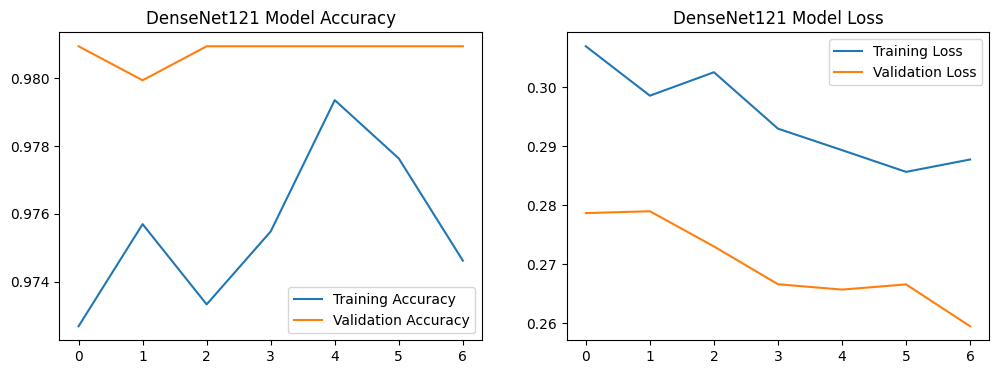

Final validation accuracy: 0.9809


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, LearningRateScheduler
import matplotlib.pyplot as plt
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from google.colab import drive
import shutil
import datetime

# Mount Google Drive
drive.mount('/content/drive')

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
INITIAL_LEARNING_RATE = 1e-4
NUM_CLASSES = 5 # Adjust based on your number of classes


# Leave it as None to start from scratch or use the latest checkpoint
CUSTOM_MODEL_PATH = '/content/drive/MyDrive/model_training/densenet121_training_20241011_015937/checkpoints/densenet_epoch_22_val_acc_0.9829.keras'

# Set this variable to the epoch number you want to start from when loading a custom model
INITIAL_EPOCH = 23  # Change this to the  epoch number

# Create directories for saving model checkpoints and logs
drive_base_path = '/content/drive/MyDrive/model_training'  # Base directory in Drive
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f'densenet121_training_{current_time}'
experiment_dir = os.path.join(drive_base_path, experiment_name)

# Create directories in Drive
checkpoint_dir = os.path.join(experiment_dir, 'checkpoints')
logs_dir = os.path.join(experiment_dir, 'logs')
best_model_dir = os.path.join(experiment_dir, 'best_model')

# Create all directories
for directory in [checkpoint_dir, logs_dir, best_model_dir]:
    os.makedirs(directory, exist_ok=True)

# Define the model architecture
def build_model(num_classes, img_size=224):
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(1024,
              activation='relu',
              kernel_regularizer=l2(0.01),
              name='dense_1024')(x)
    x = Dropout(0.5, name='dropout_1')(x)

    x = Dense(512,
              activation='relu',
              kernel_regularizer=l2(0.01),
              name='dense_512')(x)
    x = Dropout(0.5, name='dropout_2')(x)

    output = Dense(num_classes,
                  activation='softmax',
                  name='predictions')(x)

    model = Model(inputs=base_model.input,
                 outputs=output,
                 name='densenet121_transfer')

    base_model.trainable = False

    return model

# Custom callback to save best model to Drive
class SaveBestModelToDrive(tf.keras.callbacks.Callback):
    def __init__(self, best_model_dir):
        super(SaveBestModelToDrive, self).__init__()
        self.best_model_dir = best_model_dir
        self.best_val_accuracy = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_accuracy = logs.get('val_accuracy')
        if current_val_accuracy > self.best_val_accuracy:
            self.best_val_accuracy = current_val_accuracy

            # Save model with timestamp and accuracy
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            model_name = f'best_model_epoch_{epoch:03d}_acc_{current_val_accuracy:.4f}_{timestamp}.keras'
            model_path = os.path.join(self.best_model_dir, model_name)

            self.model.save(model_path)
            print(f'\nSaved new best model to Drive: {model_name}')

            # Keep only the 3 best models to save space
            existing_models = sorted(os.listdir(self.best_model_dir))
            if len(existing_models) > 3:
                os.remove(os.path.join(self.best_model_dir, existing_models[0]))

# Learning rate schedule
def lr_schedule(epoch):
    lr = INITIAL_LEARNING_RATE
    if epoch > 18:
        lr *= 0.1
    if epoch > 29:
        lr *= 0.1
    return lr

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'densenet_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras'),
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    SaveBestModelToDrive(best_model_dir),  # Custom callback for saving to Drive
    EarlyStopping(
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    CSVLogger(
        os.path.join(logs_dir, 'densenet_training_log.csv'),
        append=True
    ),
    LearningRateScheduler(lr_schedule)
]

# Function to find the latest checkpoint
def find_latest_checkpoint():
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith('.keras')]
    if not checkpoints:
        return None, 0
    latest = max(checkpoints, key=lambda x: os.path.getctime(os.path.join(checkpoint_dir, x)))
    epoch = int(latest.split('_')[2])
    return os.path.join(checkpoint_dir, latest), epoch

# Try to load existing checkpoint or create new model
if CUSTOM_MODEL_PATH:
    print(f"Loading model from provided path: {CUSTOM_MODEL_PATH}")
    try:
        model = tf.keras.models.load_model(CUSTOM_MODEL_PATH)
        print(f"Model loaded successfully. Starting from epoch {INITIAL_EPOCH}")
        initial_epoch = INITIAL_EPOCH
    except Exception as e:
        print(f"Error loading model from provided path: {e}")
        print("Starting training from scratch")
        model = build_model(NUM_CLASSES)
        initial_epoch = 0
else:
    latest_checkpoint, checkpoint_epoch = find_latest_checkpoint()
    if latest_checkpoint:
        print(f"Found existing model checkpoint: {latest_checkpoint}")
        try:
            model = tf.keras.models.load_model(latest_checkpoint)
            initial_epoch = checkpoint_epoch
            print(f"Resuming training from epoch {initial_epoch}")
        except Exception as e:
            print(f"Error loading checkpoint: {e}")
            print("Starting training from scratch")
            model = build_model(NUM_CLASSES)
            initial_epoch = 0
    else:
        print("No existing checkpoint found. Starting training from scratch")
        model = build_model(NUM_CLASSES)
        initial_epoch = 0

# Compile the model
optimizer = Adam(learning_rate=INITIAL_LEARNING_RATE, clipnorm=1.0)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Save final model to Drive
final_model_path = os.path.join(experiment_dir, 'final_model', 'densenet121_final_model.keras')
os.makedirs(os.path.join(experiment_dir, 'final_model'), exist_ok=True)
model.save(final_model_path)

# Plot and save training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('DenseNet121 Model Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('DenseNet121 Model Loss')

# Save plot to Drive
plot_path = os.path.join(experiment_dir, 'training_history.png')
plt.savefig(plot_path)
plt.show()

# Save training history to Drive
import json
history_path = os.path.join(experiment_dir, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history.history, f)

# Print final accuracy
final_accuracy = history.history['val_accuracy'][-1]
print(f"Final validation accuracy: {final_accuracy:.4f}")

# Save training summary to Drive
summary_path = os.path.join(experiment_dir, 'training_summary.txt')
with open(summary_path, 'w') as f:
    f.write(f"Training completed at: {datetime.datetime.now()}\n")
    f.write(f"Final validation accuracy: {final_accuracy:.4f}\n")
    f.write(f"Total epochs trained: {len(history.history['accuracy'])}\n")
    f.write(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}\n")

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model from the .keras file
model = tf.keras.models.load_model('/content/drive/MyDrive/model_training/densenet121_training_20241011_015937/best_model/best_model_epoch_021_acc_0.9829_20241011_054440.keras')

# Function to load and preprocess an image
def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize to [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Function to make predictions on the image
def predict_image(model, img):
    class_names = ['Alternaria', 'Anthracnose', 'Bacterial Blight', 'Cercospora', 'Healthy']
    preds = model.predict(img)

    # Print predicted probabilities
    print("Predicted probabilities:", preds)

    # Find the index of the class with the highest probability
    predicted_class_index = np.argmax(preds)
    predicted_class = class_names[predicted_class_index]

    print("Predicted class:", predicted_class)

# Function to apply data augmentation
def augment_image(img_array):
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True
    )
    img_array = np.array(img_array)
    aug_iter = datagen.flow(img_array, batch_size=1)
    augmented_img = next(aug_iter)[0]
    return augmented_img

# Example: Test an image
image_path = '/content/drive/MyDrive/Anthracnose(1).png'

# Load the original image and make a prediction
original_img = load_and_preprocess_image(image_path)
predict_image(model, original_img)

# Load the image, augment it, and make another prediction
augmented_img = augment_image(original_img)

# Ensure the augmented image has the right shape before predicting
augmented_img = np.expand_dims(augmented_img, axis=0)  # Add batch dimension back
predict_image(model, augmented_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted probabilities: [[0.00584034 0.31098852 0.00598001 0.6130851  0.06410599]]
Predicted class: Cercospora
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Predicted probabilities: [[0.01361956 0.35992268 0.01078847 0.19075166 0.42491767]]
Predicted class: Healthy


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 266s 8s/step

Classification Report:
                  precision    recall  f1-score   support

      Alternaria       0.97      0.99      0.98       196
     Anthracnose       0.99      0.98      0.98       196
Bacterial_Blight       0.99      0.98      0.98       196
      Cercospora       0.98      0.97      0.98       196
         Healthy       1.00      1.00      1.00       219

        accuracy                           0.99      1003
       macro avg       0.99      0.99      0.99      1003
    weighted avg       0.99      0.99      0.99      1003



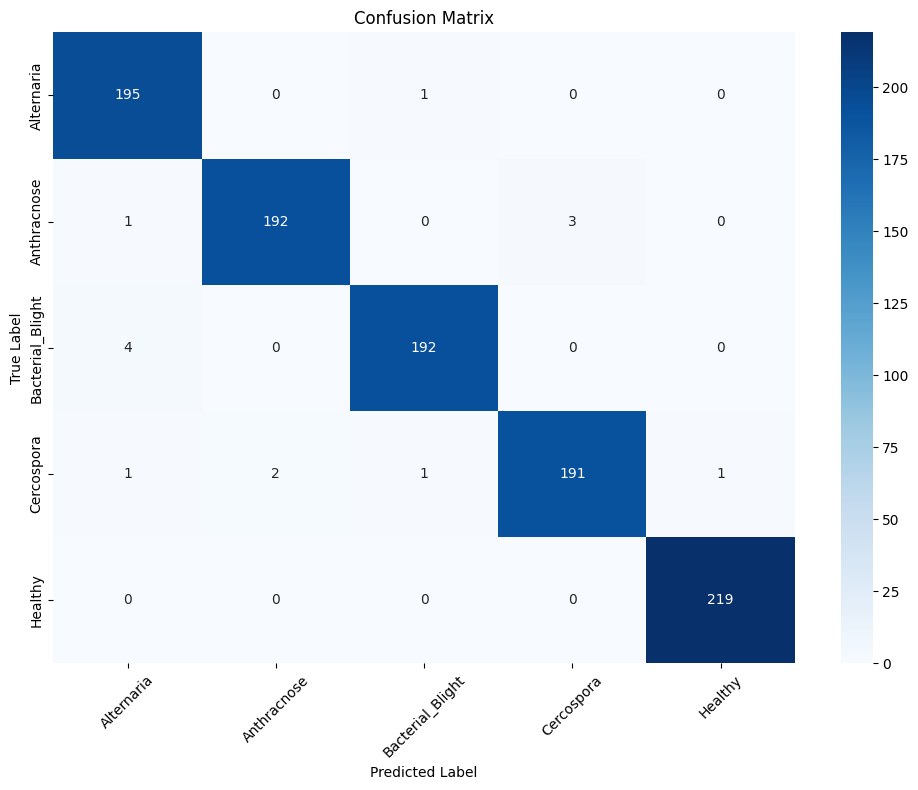


Overall Accuracy: 0.9860418743768694

Per-class Metrics:

Alternaria:
Precision: 0.9701
Recall: 0.9949
F1-score: 0.9824

Anthracnose:
Precision: 0.9897
Recall: 0.9796
F1-score: 0.9846

Bacterial_Blight:
Precision: 0.9897
Recall: 0.9796
F1-score: 0.9846

Cercospora:
Precision: 0.9845
Recall: 0.9745
F1-score: 0.9795

Healthy:
Precision: 0.9955
Recall: 1.0000
F1-score: 0.9977


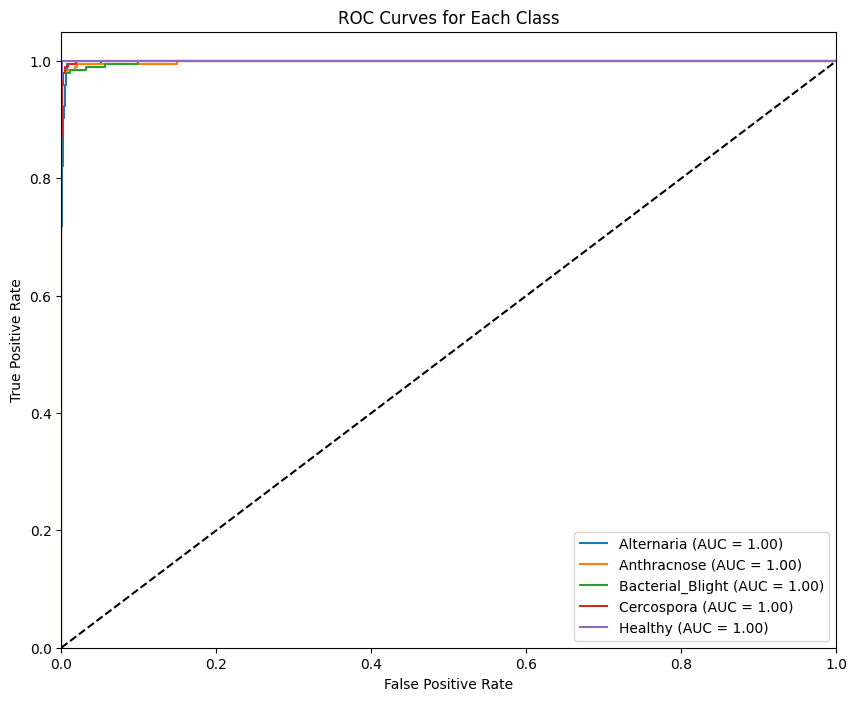

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model_path = '/content/drive/MyDrive/model_training/densenet121_training_20241012_091625/final_model/densenet121_final_model.keras'  # Update with your model path
model = tf.keras.models.load_model(model_path)

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate and print metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate overall metrics
accuracy = np.sum(y_pred == y_true) / len(y_true)

# Calculate per-class metrics
class_metrics = {}
for i, class_name in enumerate(class_labels):
    true_class = (y_true == i)
    pred_class = (y_pred == i)

    # True Positives, False Positives, False Negatives
    tp = np.sum(true_class & pred_class)3
    fp = np.sum(~true_class & pred_class)
    fn = np.sum(true_class & ~pred_class)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    class_metrics[class_name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Print detailed metrics
print("\nOverall Accuracy:", accuracy)
print("\nPer-class Metrics:")
for class_name, metrics in class_metrics.items():
    print(f"\n{class_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# Save predictions to a file (optional)
predictions_data = {
    'True Labels': y_true,
    'Predicted Labels': y_pred,
    'Class Names': [class_labels[i] for i in y_true]
}
np.save('model_predictions.npy', predictions_data)

# Calculate and visualize ROC curves for each class
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_true == i).astype(int)
    y_pred_prob = y_pred_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.show()

FINE TUNING CODE FOR DENSENET121

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, LearningRateScheduler
import datetime
import matplotlib.pyplot as plt
import json

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LEARNING_RATE = 1e-5
NUM_CLASSES = 5  # Adjust based on your number of classes

# Setup directories
drive_base_path = '/content/drive/MyDrive/model_tuning(1)'
current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f'densenet121_fine_tuning_{current_time}'
experiment_dir = os.path.join(drive_base_path, experiment_name)

checkpoint_dir = os.path.join(experiment_dir, 'checkpoints')
logs_dir = os.path.join(experiment_dir, 'logs')
best_model_dir = os.path.join(experiment_dir, 'best_model')

for directory in [checkpoint_dir, logs_dir, best_model_dir]:
    os.makedirs(directory, exist_ok=True)

# Custom callback to save best model to Drive
class SaveBestModelToDrive(tf.keras.callbacks.Callback):
    def __init__(self, best_model_dir):
        super(SaveBestModelToDrive, self).__init__()
        self.best_model_dir = best_model_dir
        self.best_val_accuracy = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_accuracy = logs.get('val_accuracy')
        if current_val_accuracy > self.best_val_accuracy:
            self.best_val_accuracy = current_val_accuracy
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            model_name = f'best_model_epoch_{epoch:03d}_acc_{current_val_accuracy:.4f}_{timestamp}.keras'
            model_path = os.path.join(self.best_model_dir, model_name)
            self.model.save(model_path)
            print(f'\nSaved new best model to Drive: {model_name}')
            existing_models = sorted(os.listdir(self.best_model_dir))
            if len(existing_models) > 3:
                os.remove(os.path.join(self.best_model_dir, existing_models[0]))

# Learning rate schedule
def lr_schedule(epoch):
    lr = FINE_TUNE_LEARNING_RATE
    if epoch > 8:
        lr *= 0.1
    if epoch > 17:
        lr *= 0.1
    return lr

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'densenet_fine_tuned_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras'),
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    SaveBestModelToDrive(best_model_dir),
    EarlyStopping(
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(
        os.path.join(logs_dir, 'densenet_fine_tuning_log.csv'),
        append=True
    ),
    LearningRateScheduler(lr_schedule)
]

def plot_fine_tuning_history(history, plot_path):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title('DenseNet121 Fine-Tuning Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('DenseNet121 Fine-Tuning Loss')

    plt.savefig(plot_path)
    plt.close()

def fine_tune_model(model, train_generator, validation_generator, class_weights):
    First, train only the top layers (which were randomly initialized)
    for layer in model.layers[:-4]:  # Freeze all but the last 4 layers
        layer.trainable = False

     model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history1 = model.fit(train_generator,
                         epochs=5,
                         validation_data=validation_generator,
                         class_weight=class_weights,
                         callbacks=callbacks)

    # Now, unfreeze the last 2 blocks of DenseNet121
    for layer in model.layers[-20:]:  # Adjust this number based on the DenseNet121 architecture
        layer.trainable = True

    model.compile(optimizer=Adam(learning_rate=1e-4),  # Lower learning rate
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history2 = model.fit(train_generator,
                         epochs=15,
                         validation_data=validation_generator,
                         class_weight=class_weights,
                         callbacks=callbacks)

    # Optionally, you can unfreeze more layers and continue training

    # Combine the histories
    total_history = {}
    for k in history1.history.keys():
        total_history[k] = history1.history[k] + history2.history[k]

    return model, total_history
# Main execution
if __name__ == "__main__":
    # Load the pre-trained model
    model_path = '/content/drive/MyDrive/model_tuning/densenet121_fine_tuning_20241013_173829/best_model/best_model_epoch_000_acc_0.9840_20241013_193112.keras'
    model = tf.keras.models.load_model(model_path)


    # Fine-tune the model
    fine_tuned_model, fine_tune_history = fine_tune_model(model, train_generator, validation_generator, class_weights)

    # Save the final fine-tuned model
    final_model_path = os.path.join(experiment_dir, 'final_fine_tuned_model.keras')
    fine_tuned_model.save(final_model_path)

    # Save fine-tuning history
    history_path = os.path.join(experiment_dir, 'fine_tuning_history.json')
    with open(history_path, 'w') as f:
        json.dump(fine_tune_history.history, f)

    # Plot and save fine-tuning history
    plot_path = os.path.join(experiment_dir, 'fine_tuning_history_plot.png')
    plot_fine_tuning_history(fine_tune_history, plot_path)

    # Print final accuracy
    final_accuracy = fine_tune_history.history['val_accuracy'][-1]
    print(f"Final validation accuracy after fine-tuning: {final_accuracy:.4f}")

    # Save fine-tuning summary
    summary_path = os.path.join(experiment_dir, 'fine_tuning_summary.txt')
    with open(summary_path, 'w') as f:
        f.write(f"Fine-tuning completed at: {datetime.datetime.now()}\n")
        f.write(f"Final validation accuracy: {final_accuracy:.4f}\n")
        f.write(f"Total epochs fine-tuned: {len(fine_tune_history.history['accuracy'])}\n")
        f.write(f"Best validation accuracy: {max(fine_tune_history.history['val_accuracy']):.4f}\n")

Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyboardInterrupt: 

REPORT FOR DENSENET121

32/32 ━━━━━━━━━━━━━━━━━━━━ 314s 10s/step

Classification Report:
                  precision    recall  f1-score   support

      Alternaria       0.97      0.99      0.98       196
     Anthracnose       0.99      0.97      0.98       196
Bacterial_Blight       0.99      0.97      0.98       196
      Cercospora       0.97      0.99      0.98       196
         Healthy       1.00      1.00      1.00       219

        accuracy                           0.99      1003
       macro avg       0.99      0.99      0.99      1003
    weighted avg       0.99      0.99      0.99      1003



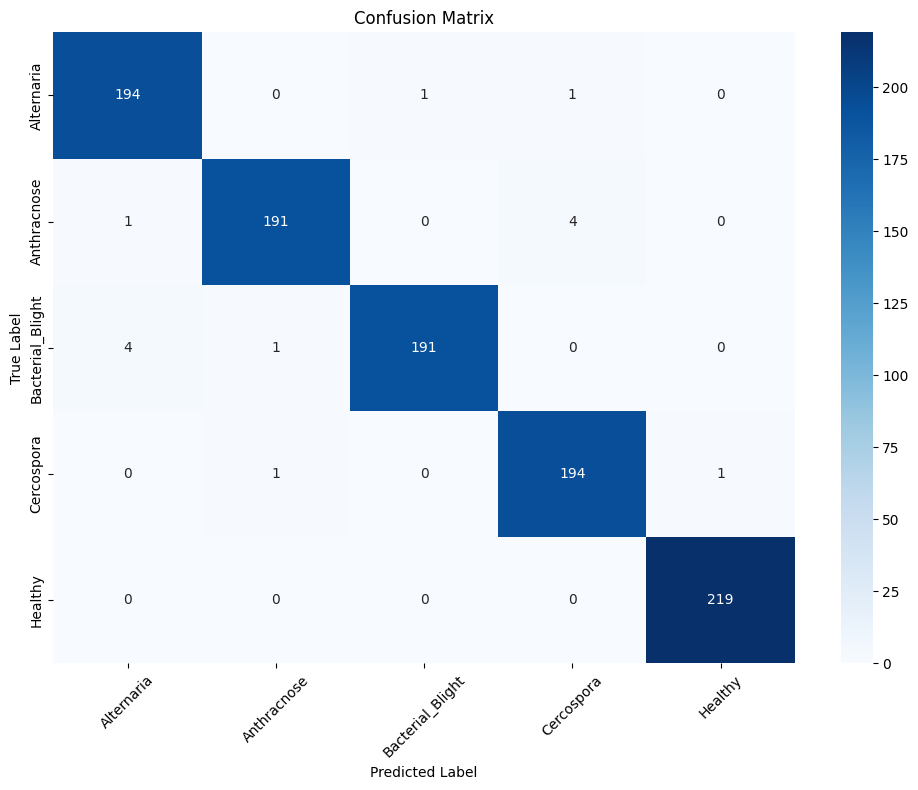


Overall Accuracy: 0.9860418743768694

Per-class Metrics:

Alternaria:
Precision: 0.9749
Recall: 0.9898
F1-score: 0.9823

Anthracnose:
Precision: 0.9896
Recall: 0.9745
F1-score: 0.9820

Bacterial_Blight:
Precision: 0.9948
Recall: 0.9745
F1-score: 0.9845

Cercospora:
Precision: 0.9749
Recall: 0.9898
F1-score: 0.9823

Healthy:
Precision: 0.9955
Recall: 1.0000
F1-score: 0.9977


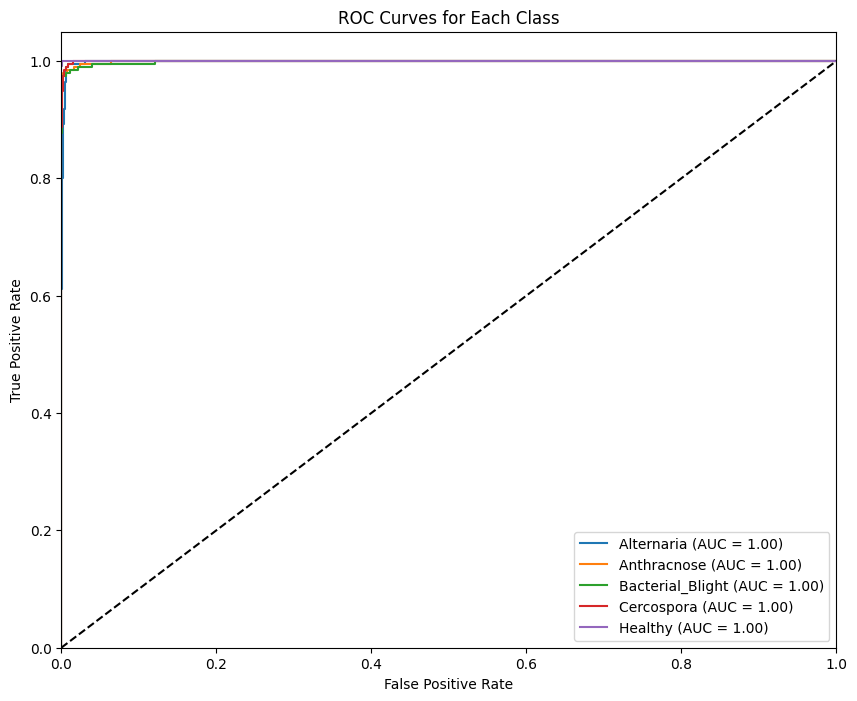

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model_path = '/content/drive/MyDrive/model_tuning/densenet121_fine_tuning_20241013_173829/final_fine_tuned_model.keras'  # Update with your model path
model = tf.keras.models.load_model(model_path)

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate and print metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate overall metrics
accuracy = np.sum(y_pred == y_true) / len(y_true)

# Calculate per-class metrics
class_metrics = {}
for i, class_name in enumerate(class_labels):
    true_class = (y_true == i)
    pred_class = (y_pred == i)

    # True Positives, False Positives, False Negatives
    tp = np.sum(true_class & pred_class)
    fp = np.sum(~true_class & pred_class)
    fn = np.sum(true_class & ~pred_class)

    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    class_metrics[class_name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Print detailed metrics
print("\nOverall Accuracy:", accuracy)
print("\nPer-class Metrics:")
for class_name, metrics in class_metrics.items():
    print(f"\n{class_name}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

# Save predictions to a file
predictions_data = {
    'True Labels': y_true,
    'Predicted Labels': y_pred,
    'Class Names': [class_labels[i] for i in y_true]
}
np.save('model_predictions.npy', predictions_data)

# Calculate and visualize ROC curves for each class
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_labels):
    y_true_binary = (y_true == i).astype(int)
    y_pred_prob = y_pred_probs[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.show()

TESTING DENSENET121

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the trained model from the .keras file
model = tf.keras.models.load_model('/content/drive/MyDrive/model_tuning/densenet121_fine_tuning_20241013_173829/final_fine_tuned_model.keras')

# Function to load and preprocess multiple images
def load_and_preprocess_images(img_paths):
    # List to store preprocessed images
    processed_images = []

    # Iterate  list of image paths
    for img_path in img_paths:
        # Load the image file, target size must match the model's input size (224, 224 for EfficientNetB0)
        img = image.load_img(img_path, target_size=(224, 224))

        # Convert the image to a numpy array
        img_array = image.img_to_array(img)

        # Rescale the pixel values to [0, 1], to match the training preprocessing
        img_array = img_array / 255.0

        # Add a batch dimension (1, 224, 224, 3)
        img_array = np.expand_dims(img_array, axis=0)

        # Append to the list
        processed_images.append(img_array)

    # Stack all the images to create a batch (N, 224, 224, 3)
    batch = np.vstack(processed_images)

    return batch


def predict_images(model, img_paths):
    # Preprocess the images
    images = load_and_preprocess_images(img_paths)

    # Perform predictions
    preds = model.predict(images)

    # Display the prediction results for each image
    for i, img_path in enumerate(img_paths):
        print(f"\nPrediction for {os.path.basename(img_path)}:")
        print("Predictions:", preds[i])


image_paths = [
    '/content/drive/MyDrive/pomegranate_split/train/Healthy/IMG_20230910_102205.jpg',
    '/content/drive/MyDrive/Anthracnose.png',
    '/content/drive/MyDrive/pomegranate_split/test/Alternaria/Alternaria_1045.jpg',
    '/content/drive/MyDrive/pomegranate_unzipped/Pomegranate Diseases Dataset/Bacterial_Blight/IMG_20230813_090033_1.jpg',
    '/content/drive/MyDrive/pomegranate_unzipped/Pomegranate Diseases Dataset/Cercospora/IMG_20230813_151756_1.jpg',
    '/content/drive/MyDrive/pomegranate_split/test/Anthracnose/Anthracnose_1174.jpg'
]

predict_images(model, image_paths)


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Prediction for IMG_20230910_102205.jpg:
Predictions: [3.6354107e-03 2.1839398e-03 1.1832857e-03 3.8590355e-04 9.9261147e-01]

Prediction for Anthracnose.png:
Predictions: [0.00923422 0.2645903  0.01364008 0.6478586  0.06467683]

Prediction for Alternaria_1045.jpg:
Predictions: [0.94277155 0.01061792 0.00167025 0.01078497 0.03415529]

Prediction for IMG_20230813_090033_1.jpg:
Predictions: [1.9586938e-03 2.2911366e-04 9.9131280e-01 6.4800060e-03 1.9422838e-05]

Prediction for IMG_20230813_151756_1.jpg:
Predictions: [4.6143360e-02 1.1627166e-02 3.6348168e-02 9.0567011e-01 2.1121537e-04]

Prediction for Anthracnose_1174.jpg:
Predictions: [2.4092280e-04 9.9548763e-01 1.9220567e-03 1.9963642e-03 3.5305129e-04]


REPORT FOR DENSENET121

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 234s 7s/step


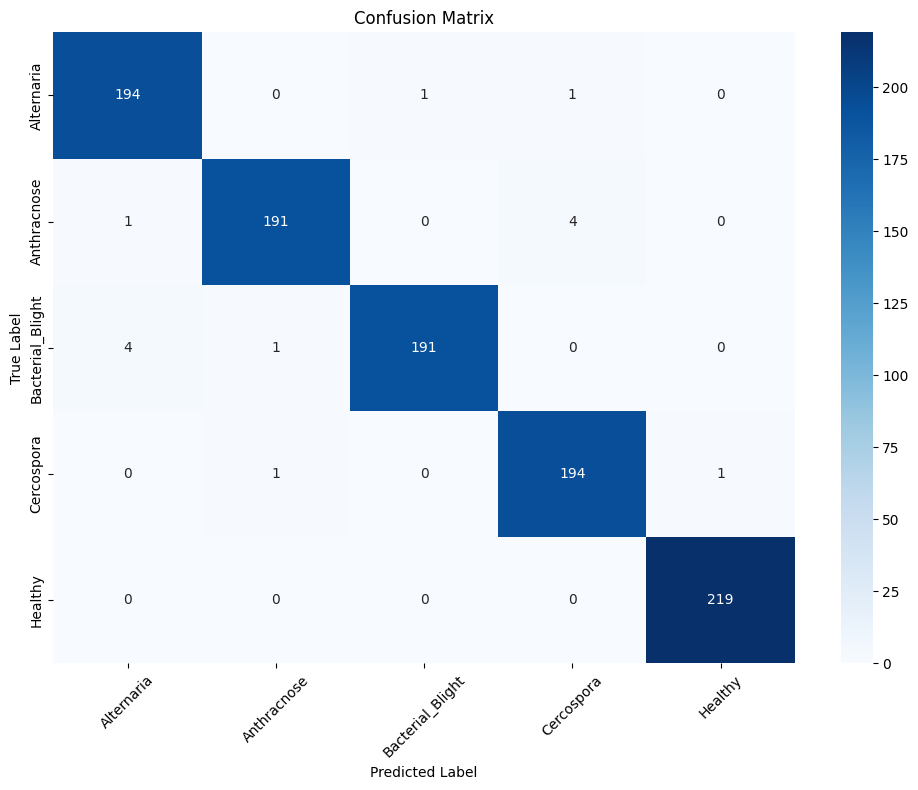

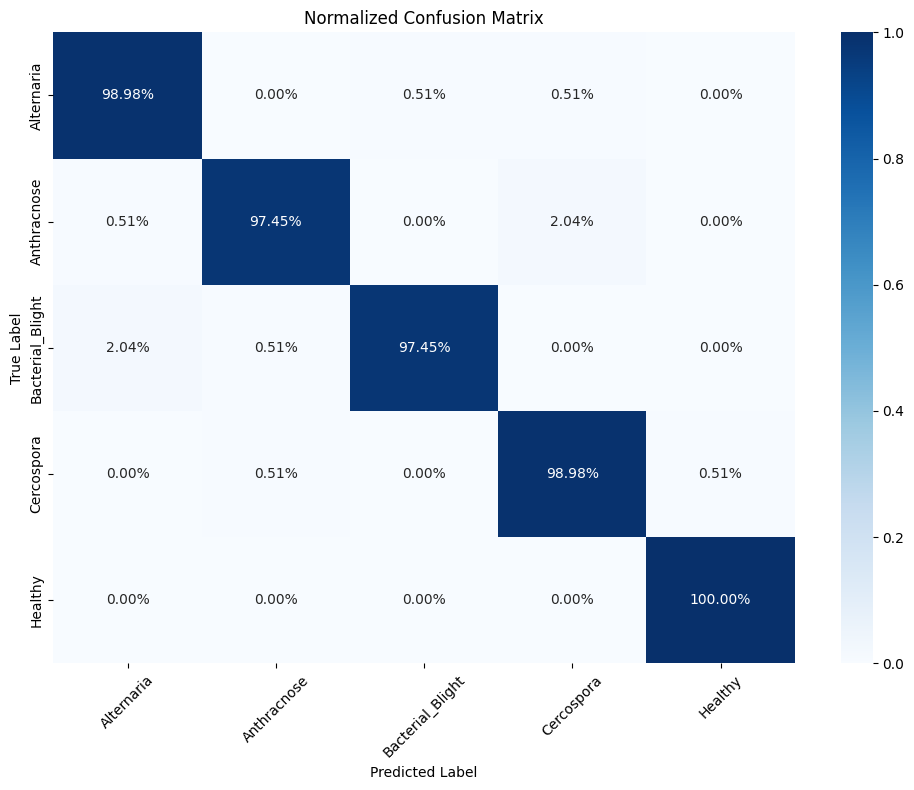

Model evaluation report saved to: /content/drive/MyDrive/model_tuning/reports/model_evaluation_report.pdf


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import os
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

# Load the trained model
model_path = '/content/drive/MyDrive/model_tuning/densenet121_fine_tuning_20241013_173829/final_fine_tuned_model.keras'  # Update with your model path
model = tf.keras.models.load_model(model_path)

# Define paths to save reports and figures
output_dir = '/content/drive/MyDrive/model_tuning/reports/'
os.makedirs(output_dir, exist_ok=True)

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate classification report and confusion matrix
classification_report_str = classification_report(y_true, y_pred, target_names=class_labels)
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
confusion_matrix_path = os.path.join(output_dir, 'confusion_matrix.png')
plt.savefig(confusion_matrix_path)
plt.show()

# Plot normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
normalized_cm_path = os.path.join(output_dir, 'normalized_confusion_matrix.png')
plt.savefig(normalized_cm_path)
plt.show()

# Calculate top-k accuracy (e.g., top-2 accuracy)
top_k = 2
top_k_correct = np.any(np.argsort(y_pred_probs, axis=1)[:, -top_k:] == y_true.reshape(-1, 1), axis=1)
top_k_accuracy = np.mean(top_k_correct)
top_k_accuracy_str = f"Top-{top_k} Accuracy: {top_k_accuracy:.4f}"

# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
per_class_accuracy_str = "\nPer-Class Accuracy:\n" + "\n".join(
    [f"{class_labels[i]}: {per_class_accuracy[i]:.4f}" for i in range(len(class_labels))]
)

# Misclassified examples
misclassified_indices = np.where(y_true != y_pred)[0]
misclassified_info = []
for idx in misclassified_indices[:5]:  # Display up to 5 examples
    file_path = test_generator.filepaths[idx]
    true_label = class_labels[y_true[idx]]
    predicted_label = class_labels[y_pred[idx]]
    misclassified_info.append(f"File: {file_path}, True: {true_label}, Predicted: {predicted_label}")
misclassified_examples_str = "\n".join(misclassified_info)

# Create a PDF to save all the reports
pdf_path = os.path.join(output_dir, 'model_evaluation_report.pdf')
c = canvas.Canvas(pdf_path, pagesize=A4)
width, height = A4

# Add classification report to PDF
c.setFont("Helvetica-Bold", 12)
c.drawString(30, height - 30, "Classification Report:")
c.setFont("Helvetica", 10)
text_obj = c.beginText(30, height - 50)
text_obj.textLines(classification_report_str)
c.drawText(text_obj)

# Add top-k accuracy to PDF
c.setFont("Helvetica-Bold", 12)
c.drawString(30, text_obj.getY() - 20, top_k_accuracy_str)

# Add per-class accuracy to PDF
c.setFont("Helvetica-Bold", 12)
c.drawString(30, text_obj.getY() - 50, "Per-Class Accuracy:")
c.setFont("Helvetica", 10)
text_obj = c.beginText(30, text_obj.getY() - 70)
text_obj.textLines(per_class_accuracy_str)
c.drawText(text_obj)

# Add misclassified examples to PDF
c.setFont("Helvetica-Bold", 12)
c.drawString(30, text_obj.getY() - 20, "Misclassified Examples (up to 5 shown):")
c.setFont("Helvetica", 10)
text_obj = c.beginText(30, text_obj.getY() - 40)
text_obj.textLines(misclassified_examples_str)
c.drawText(text_obj)

# Add confusion matrix images to the PDF
c.showPage()
c.drawImage(confusion_matrix_path, 30, height / 2, width=500, height=400)
c.showPage()
c.drawImage(normalized_cm_path, 30, height / 2, width=500, height=400)

# Save the PDF
c.save()

print(f"Model evaluation report saved to: {pdf_path}")
